# Direct Monolithic Baseline: Split-Concatenated Video-Only Input

This notebook evaluates the initial **direct monolithic baseline** for dyadic conversational anomaly detection with **Qwen2.5-Omni-7B**.

Each example is represented as a single split-concatenated audiovisual file:

- the left half contains one participant,
- the right half contains the other participant,
- the model receives the paired interaction directly,
- no transcript, VAD, participant metadata, or other external structured evidence is provided.

The task is binary classification between:

- `NORMAL`: the two participant streams belong to the same conversation;
- `ANOMALOUS`: the streams form a Wrong Partner pair.

Each 120-second interaction is divided into two 60-second segments. Qwen2.5-Omni independently classifies each segment, and the conversation-level prediction is obtained by majority vote. A tie defaults to `NORMAL`.

> **Terminology.** In this notebook, *video-only* means that no external metadata is supplied to the model. The split-concatenated `.mp4` files retain their embedded audio, and Qwen2.5-Omni processes both the visual stream and the audio contained in the video.

This baseline is intentionally monolithic: the model must perform participant attribution, audiovisual interpretation, semantic comparison, temporal assessment, and the final anomaly decision directly from the combined input. The later participant-centric pipeline was introduced after this baseline showed a strong bias toward `NORMAL`.

## 1. Environment Setup

Install the libraries required for Qwen2.5-Omni inference and video preprocessing.

In [ ]:
!pip uninstall -y transformers
!pip install -U "transformers>=4.57.0" accelerate bitsandbytes sentencepiece
!pip install -U qwen-omni-utils decord ffmpeg-python
!apt-get update -qq
!apt-get install -y -qq ffmpeg

Found existing installation: transformers 5.12.0
Uninstalling transformers-5.12.0:
  Successfully uninstalled transformers-5.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 149.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 140.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 76.8 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 2. Google Drive and Dataset Paths

The experiment expects `dataset.zip` in Google Drive. The archive contains the preconstructed split-concatenated NORMAL and Wrong Partner videos.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import zipfile
import json
import re
import subprocess
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

DRIVE_ROOT = Path("/content/drive/MyDrive")

DATASET_ZIP = DRIVE_ROOT / "dataset.zip"

WORK_DIR = Path("/content/split_concat_video_only_baseline")
DATASET_DIR = WORK_DIR / "dataset"

print("dataset.zip exists:", DATASET_ZIP.exists(), DATASET_ZIP)

## 3. Extract the Split-Concatenated Dataset

The dataset archive is extracted once per Colab runtime. The code automatically locates the directory containing the NORMAL and Wrong Partner video folders even if the ZIP contains an additional nested directory.

In [ ]:
def extract_zip_once(zip_path: Path, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    marker = out_dir / ".extracted"

    if marker.exists():
        print(f"Already extracted: {zip_path.name} -> {out_dir}")
        return

    print(f"Extracting {zip_path} -> {out_dir}")

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)

    marker.write_text("done")


def find_dir_containing(base: Path, required_child_names):
    required_child_names = set(required_child_names)
    candidates = [base] + [p for p in base.rglob("*") if p.is_dir()]

    for p in candidates:
        children = {c.name for c in p.iterdir() if c.is_dir()}
        if required_child_names.issubset(children):
            return p

    raise FileNotFoundError(
        f"Could not find directory under {base} containing {required_child_names}"
    )


extract_zip_once(DATASET_ZIP, DATASET_DIR)

dataset_root = find_dir_containing(
    DATASET_DIR,
    ["normal_data_amerged", "anomaly_wrong_partner_amerged"],
)

normal_video_dir = dataset_root / "normal_data_amerged"
wrong_video_dir = dataset_root / "anomaly_wrong_partner_amerged"

normal_videos = sorted(normal_video_dir.glob("*.mp4"))
wrong_videos = sorted(wrong_video_dir.glob("*.mp4"))

print("dataset_root:", dataset_root)
print("Normal videos:", len(normal_videos))
print("Wrong Partner videos:", len(wrong_videos))

## 4. Load Qwen2.5-Omni

Qwen2.5-Omni receives each split-concatenated video together with its embedded audio. No external transcript, VAD, or participant metadata is added to the prompt.

In [ ]:
import torch
from transformers import Qwen2_5OmniThinkerForConditionalGeneration, Qwen2_5OmniProcessor
from qwen_omni_utils import process_mm_info

MODEL_ID = "Qwen/Qwen2.5-Omni-7B"

model = Qwen2_5OmniThinkerForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype="auto",
    device_map="auto",
)

processor = Qwen2_5OmniProcessor.from_pretrained(MODEL_ID)

print("Loaded:", MODEL_ID)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/13.2k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/233k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1346 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/832 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-Omni-7B


## 5. Inference Helpers

The helper below sends one audiovisual segment to Qwen2.5-Omni and parses the model response as JSON.

In [ ]:
def extract_json_from_text(text: str):
    text = text.strip()

    text = re.sub(r"^```(?:json)?", "", text.strip(), flags=re.IGNORECASE)
    text = re.sub(r"```$", "", text.strip())

    try:
        return json.loads(text)
    except Exception:
        pass

    start = text.find("{")
    if start == -1:
        return {"parse_error": True, "raw_output": text}

    depth = 0
    for i in range(start, len(text)):
        if text[i] == "{":
            depth += 1
        elif text[i] == "}":
            depth -= 1
            if depth == 0:
                candidate = text[start:i + 1]
                try:
                    return json.loads(candidate)
                except Exception:
                    return {
                        "parse_error": True,
                        "raw_output": text,
                        "json_candidate": candidate,
                    }

    return {"parse_error": True, "raw_output": text}


def qwen_video_text(video_path: str, prompt: str, max_new_tokens: int = 450):
    messages = [
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": (
                        "You are Qwen, a virtual human developed by the Qwen Team, "
                        "Alibaba Group, capable of perceiving auditory and visual inputs, "
                        "as well as generating text and speech."
                    )
                }
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "video", "video": video_path, "fps": 7.0},
                {"type": "text", "text": prompt},
            ],
        },
    ]

    text = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )

    audios, images, videos = process_mm_info(
        messages,
        use_audio_in_video=True,
    )

    inputs = processor(
        text=text,
        audio=audios,
        images=images,
        videos=videos,
        return_tensors="pt",
        padding=True,
        use_audio_in_video=True,
    )

    inputs = inputs.to(model.device)

    print("Input tokens:", inputs["input_ids"].shape[1])

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    generated = processor.batch_decode(
        output_ids[:, inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    return generated

## 6. Build the 60-Case Baseline Set

The baseline contains 30 NORMAL and 30 Wrong Partner interactions. Gold labels are used only for evaluation and are never included in the model prompt.

In [ ]:
def build_cases_from_videos(normal_videos, wrong_videos):
    cases = []

    for video_path in normal_videos:
        cases.append({
            "case_id": Path(video_path).stem,
            "video_path": str(video_path),
            "gold_label": "NORMAL",
            "gold_anomaly_type": "none",
        })

    for video_path in wrong_videos:
        cases.append({
            "case_id": Path(video_path).stem,
            "video_path": str(video_path),
            "gold_label": "ANOMALOUS",
            "gold_anomaly_type": "wrong_partner",
        })

    return cases


cases = build_cases_from_videos(normal_videos, wrong_videos)

print("Total cases:", len(cases))
print("Normal:", sum(c["gold_label"] == "NORMAL" for c in cases))
print("Wrong:", sum(c["gold_label"] == "ANOMALOUS" for c in cases))

Total cases: 60
Normal: 30
Wrong: 30


## 7. Segment Preprocessing

Each 120-second interaction is divided into two 60-second segments. The segments are resized for inference while retaining their audio.

No metadata are read or attached during this step.

In [ ]:
ENSEMBLE_SEGMENTS = [
    (0, 60),
    (60, 60),
]

VIDEO_ONLY_PREP_DIR = Path(
    "/content/drive/MyDrive/qwen_split_concat_video_only/preprocessed_segments_60s"
)
VIDEO_ONLY_OUT_DIR = Path(
    "/content/drive/MyDrive/qwen_split_concat_video_only/outputs_ensemble"
)

VIDEO_ONLY_PREP_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_ONLY_OUT_DIR.mkdir(parents=True, exist_ok=True)


def safe_name(x):
    return str(x).replace("/", "_").replace(" ", "_")


def video_has_audio(path):
    cmd = [
        "ffprobe", "-v", "error",
        "-select_streams", "a",
        "-show_entries", "stream=index",
        "-of", "csv=p=0",
        str(path)
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    return bool(result.stdout.strip())


def segmented_split_concat_path(video_path, segment_idx):
    video_path = Path(video_path)
    out_dir = VIDEO_ONLY_PREP_DIR / safe_name(video_path.stem)
    out_dir.mkdir(parents=True, exist_ok=True)

    return out_dir / f"{safe_name(video_path.stem)}_seg{segment_idx}_60s.mp4"


def preprocess_video_segment(
    input_path: str,
    output_path: Path,
    start: int,
    seconds: int = 60,
    fps: int = 30,
):
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and output_path.stat().st_size > 0:
        if video_has_audio(output_path):
            return str(output_path)
        output_path.unlink(missing_ok=True)

    cmd = [
        "ffmpeg", "-y",
        "-ss", str(start),
        "-i", input_path,
        "-t", str(seconds),
        "-vf", f"scale=480:-2,fps={fps},format=yuv420p",
        "-c:v", "libx264",
        "-crf", "23",
        "-preset", "veryfast",
        "-c:a", "aac",
        "-ar", "16000",
        "-ac", "1",
        str(output_path)
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if (
        result.returncode != 0
        or not output_path.exists()
        or output_path.stat().st_size == 0
    ):
        print("Empty or failed segment:", input_path, "start:", start)
        return None

    if not video_has_audio(output_path):
        print("Segment has no audio, skipping:", output_path)
        output_path.unlink(missing_ok=True)
        return None

    return str(output_path)


for case in tqdm(cases):
    case["segments"] = []

    for seg_idx, (start, duration) in enumerate(ENSEMBLE_SEGMENTS):
        out_path = segmented_split_concat_path(case["video_path"], seg_idx)

        seg_video_path = preprocess_video_segment(
            input_path=case["video_path"],
            output_path=out_path,
            start=start,
            seconds=duration,
            fps=30,
        )

        if seg_video_path is None:
            continue

        case["segments"].append({
            "segment_idx": seg_idx,
            "start": start,
            "duration": duration,
            "video_path": seg_video_path,
        })

print("Segment preprocessing done.")

## 8. Video-Only Prompt

The prompt asks Qwen2.5-Omni to judge whether the two streams form one coherent conversation using only the audiovisual evidence contained in the split-concatenated video.

In [ ]:
SPLIT_CONCAT_VIDEO_ONLY_PROMPT = """
You are given a split-concatenated video of a dyadic conversation.

The video layout is fixed:
- The left half shows the left participant.
- The right half shows the right participant.
- The two participants are expected to be part of the same conversation.

Your task is to decide whether this video segment represents a NORMAL conversation or an ANOMALOUS wrong-partner conversation.

A NORMAL conversation means:
- the left and right participants appear to be involved in the same interaction,
- their speech, reactions, timing, and turn-taking behavior are plausible for a shared conversation,
- the conversation appears coherent.

An ANOMALOUS conversation means:
- the two participants appear to come from different conversations,
- their topics, responses, or intentions do not match,
- their reactions or turn-taking do not plausibly correspond to each other,
- the interaction does not look like a shared conversation.

Use only the video and audio evidence.
Do not assume any transcript or external metadata is available.

Focus on:
- whether both participants seem to be talking about the same thing,
- whether their reactions are coherent,
- whether the timing and turn-taking are plausible,
- whether the left and right participants appear to belong to the same conversation.

Return ONLY valid JSON in this exact format:

{
  "left_topic": "brief estimate of what the left participant seems to be talking about",
  "right_topic": "brief estimate of what the right participant seems to be talking about",
  "topic_match": "high|medium|low|unknown",
  "interaction_coherence": "high|medium|low",
  "visual_temporal_coherence": "high|medium|low",
  "decision": "NORMAL|ANOMALOUS",
  "confidence": "high|medium|low",
  "reason": "brief explanation"
}
"""

## 9. Segment-Level Inference

Predictions are cached after every segment so that a long Colab run can resume without recomputing already completed model calls.

In [ ]:
video_only_cache_path = VIDEO_ONLY_OUT_DIR / "split_concat_video_only_segment_analyses.json"

if video_only_cache_path.exists():
    video_only_cache = json.loads(video_only_cache_path.read_text(encoding="utf-8"))
else:
    video_only_cache = {}


def split_concat_video_only_segment_key(case, seg):
    return f'{case["case_id"]}::seg{seg["segment_idx"]}::{seg["video_path"]}'


def analyze_split_concat_video_only_segment(case, seg):
    key = split_concat_video_only_segment_key(case, seg)

    if key in video_only_cache:
        return video_only_cache[key]

    raw = qwen_video_text(
        video_path=seg["video_path"],
        prompt=SPLIT_CONCAT_VIDEO_ONLY_PROMPT,
        max_new_tokens=450
    )

    parsed = extract_json_from_text(raw)

    record = {
        "case_id": case["case_id"],
        "gold_label": case["gold_label"],
        "gold_anomaly_type": case["gold_anomaly_type"],
        "segment_idx": seg["segment_idx"],
        "start": seg["start"],
        "duration": seg["duration"],
        "video_path": seg["video_path"],
        "raw_output": raw,
        "parsed": parsed,
    }

    video_only_cache[key] = record

    video_only_cache_path.write_text(
        json.dumps(video_only_cache, indent=2, ensure_ascii=False),
        encoding="utf-8"
    )

    return record

In [ ]:
video_only_ensemble_results = []

for case in tqdm(cases):
    for seg in case["segments"]:
        rec = analyze_split_concat_video_only_segment(case, seg)
        video_only_ensemble_results.append(rec)

print("Total video-only segment analyses:", len(video_only_ensemble_results))

## 10. Conversation-Level Majority Vote

The two segment predictions are aggregated into a single conversation-level decision. `ANOMALOUS` requires a strict majority; a 1-1 tie is therefore classified as `NORMAL`.

In [ ]:
def normalize_segment_prediction(parsed):
    if not isinstance(parsed, dict):
        return None

    decision = parsed.get("decision", None)

    if decision == "NORMAL":
        return "NORMAL"

    if decision == "ANOMALOUS":
        return "ANOMALOUS"

    return None


def confidence_to_score(conf):
    if isinstance(conf, (int, float)):
        return float(conf)

    if not isinstance(conf, str):
        return 0.0

    conf = conf.lower().strip()

    if conf == "high":
        return 1.0
    if conf == "medium":
        return 0.66
    if conf == "low":
        return 0.33

    return 0.0

In [ ]:
video_only_case_to_results = defaultdict(list)

for r in video_only_ensemble_results:
    video_only_case_to_results[r["case_id"]].append(r)


video_only_ensemble_rows = []

for case in cases:
    case_results = video_only_case_to_results[case["case_id"]]

    votes = []

    for r in case_results:
        parsed = r.get("parsed", {})
        vote = normalize_segment_prediction(parsed)

        if vote is not None:
            votes.append(vote)

    counts = Counter(votes)

    if counts["ANOMALOUS"] > counts["NORMAL"]:
        final_label = "ANOMALOUS"
        final_anomaly_type = "wrong_partner"
        final_reason = "Majority vote favors ANOMALOUS."
    else:
        final_label = "NORMAL"
        final_anomaly_type = "none"
        final_reason = "Majority vote favors NORMAL or is tied."

    video_only_ensemble_rows.append({
        "case_id": case["case_id"],
        "gold_label": case["gold_label"],
        "gold_anomaly_type": case["gold_anomaly_type"],
        "segment_votes": votes,
        "num_normal_votes": counts["NORMAL"],
        "num_anomalous_votes": counts["ANOMALOUS"],
        "ensemble_label": final_label,
        "ensemble_anomaly_type": final_anomaly_type,
        "ensemble_reason": final_reason,
    })


video_only_ensemble_df = pd.DataFrame(video_only_ensemble_rows)
display(video_only_ensemble_df)

,case_id,gold_label,gold_anomaly_type,segment_votes,num_normal_votes,num_anomalous_votes,ensemble_label,ensemble_anomaly_type,ensemble_reason
0,V00_S2017_I00001160__NORMAL__P1273A__P2072A,NORMAL,none,"[NORMAL, NORMAL]",2,0,NORMAL,none,Majority vote favors NORMAL or is tied.
1,V00_S2018_I00001009__NORMAL__P1273A__P1274A,NORMAL,none,"[NORMAL, NORMAL]",2,0,NORMAL,none,Majority vote favors NORMAL or is tied.
2,V00_S2019_I00001101__NORMAL__P1272A__P1274A,NORMAL,none,"[NORMAL, NORMAL]",2,0,NORMAL,none,Majority vote favors NORMAL or is tied.
3,V00_S2035_I00000995__NORMAL__P1292A__P1293A,NORMAL,none,"[NORMAL, NORMAL]",2,0,NORMAL,none,Majority vote favors NORMAL or is tied.
4,V00_S2036_I00000709__NORMAL__P1294A__P1293A,NORMAL,none,"[NORMAL, NORMAL]",2,0,NORMAL,none,Majority vote favors NORMAL or is tied.
5,V00_S2048_I00000692__NORMAL__P1306A__P1305A,NORMAL,none,"[ANOMALOUS, NORMAL]",1,1,NORMAL,none,Majority vote favors NORMAL or is tied.
6,V00_S2049_I00001111__NORMAL__P1306A__P1304A,NORMAL,none,"[NORMAL, NORMAL]",2,0,NORMAL,none,Majority vote favors NORMAL or is tied.
7,V00_S2050_I00001125__NORMAL__P1308A__P1307A,NORMAL,none,"[NORMAL, NORMAL]",2,0,NORMAL,none,Majority vote favors NORMAL or is tied.
8,V00_S2050_I00001126__NORMAL__P1308A__P1307A,NORMAL,none,"[NORMAL, NORMAL]",2,0,NORMAL,none,Majority vote favors NORMAL or is tied.
9,V00_S2050_I00001129__NORMAL__P1308A__P1307A,NORMAL,none,"[NORMAL, NORMAL]",2,0,NORMAL,none,Majority vote favors NORMAL or is tied.


## 11. Baseline Evaluation

In [ ]:
y_true = video_only_ensemble_df["gold_label"].tolist()
y_pred = video_only_ensemble_df["ensemble_label"].tolist()

acc = accuracy_score(y_true, y_pred)

print("Video-only Accuracy:", round(acc, 4))
print()
print(classification_report(
    y_true,
    y_pred,
    labels=["NORMAL", "ANOMALOUS"],
    digits=4
))

Video-only Accuracy: 0.5167

              precision    recall  f1-score   support

      NORMAL     0.5085    1.0000    0.6742        30
   ANOMALOUS     1.0000    0.0333    0.0645        30

    accuracy                         0.5167        60
   macro avg     0.7542    0.5167    0.3693        60
weighted avg     0.7542    0.5167    0.3693        60



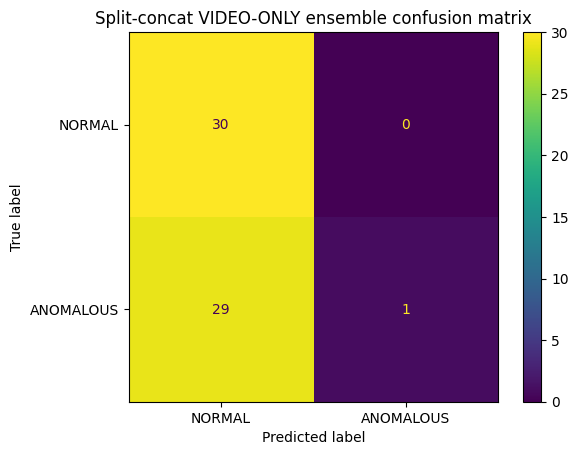

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=["NORMAL", "ANOMALOUS"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "ANOMALOUS"]
)

disp.plot(values_format="d")
plt.title("Split-concat VIDEO-ONLY ensemble confusion matrix")
plt.show()

### Observed Baseline Behaviour

The direct split-concatenated baseline classified all 30 NORMAL cases correctly but detected only 1 of the 30 Wrong Partner cases. The resulting accuracy was **51.67%**, corresponding to a strong collapse toward the `NORMAL` class.

This failure motivated the later participant-centric redesign, where each participant is analysed independently before semantic, temporal, and participation evidence are consolidated.

## 12. Save Conversation-Level Predictions

In [ ]:
video_only_csv_path = VIDEO_ONLY_OUT_DIR / "video_only_ensemble_case_results.csv"
video_only_json_path = VIDEO_ONLY_OUT_DIR / "video_only_ensemble_case_results.json"

video_only_ensemble_df.to_csv(video_only_csv_path, index=False)

video_only_ensemble_df.to_json(
    video_only_json_path,
    orient="records",
    indent=2,
    force_ascii=False
)

print("Saved CSV:", video_only_csv_path)
print("Saved JSON:", video_only_json_path)

Saved CSV: /content/drive/MyDrive/qwen_split_concat_video_only/outputs_ensemble/video_only_ensemble_case_results.csv
Saved JSON: /content/drive/MyDrive/qwen_split_concat_video_only/outputs_ensemble/video_only_ensemble_case_results.json
